# Engineering fundamentals

Small numerical experiments on the physics and numerics I lean on elsewhere.
No external data. The notebook is built in short steps - each step declares its
parameters, does one calculation, draws one plot, and ends with a note on what
the plot shows. Every result is checked against a closed-form solution.

**Steps**

1. Biot number - when is a body a single temperature?
2. Fourier number - how long does the transient last?
3. Lumped capacitance - the analytic transient
4. Forward Euler - a first numerical solution
5. Forward Euler - the stability limit
6. Backward Euler and RK4
7. Order of accuracy
8. 1-D steady conduction with heat generation - analytic
9. Finite differences and grid convergence

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

---
## Step 1 - Biot number: when is a body a single temperature?

A solid cooling in a fluid has two resistances in series: conduction inside the
body and convection at its surface. The **Biot number** is their ratio,

$$ Bi \;=\; \frac{h\,L_c}{k}, \qquad L_c \;=\; \frac{V}{A_s} $$

where $h$ is the surface heat-transfer coefficient, $k$ the solid conductivity,
and $L_c$ a characteristic length (volume over cooled area).

If $Bi < 0.1$ the inside of the body is nearly uniform and a **single-temperature
("lumped") model** is accurate. Above that, temperature gradients inside the
body matter and it needs to be resolved in space.

### 1a. Parameters - a prismatic battery cell cooled on its two large faces

In [2]:
W, H, Th = 0.148, 0.091, 0.0269      # cell width, height, thickness [m]
k_cell = 0.9                          # through-plane conductivity [W/m-K]
h_list = [5, 25, 100, 400]            # h [W/m2-K]: natural air -> forced air -> liquid cold plate

### 1b. Compute the characteristic length and the Biot number for each cooling case

In [3]:
A_faces = 2 * W * H                    # cooled area (two faces) [m2]
V_cell = W * H * Th                    # volume [m3]
Lc = V_cell / A_faces                  # characteristic length [m]  (~ half-thickness)

Bi_list = [h * Lc / k_cell for h in h_list]
for h, Bi in zip(h_list, Bi_list):
    print(f"h = {h:4d} W/m2-K   ->   Bi = {Bi:6.3f}   "
          f"({'lumped OK' if Bi < 0.1 else 'needs a spatial model'})")

h =    5 W/m2-K   ->   Bi =  0.075   (lumped OK)
h =   25 W/m2-K   ->   Bi =  0.374   (needs a spatial model)
h =  100 W/m2-K   ->   Bi =  1.494   (needs a spatial model)
h =  400 W/m2-K   ->   Bi =  5.978   (needs a spatial model)


### 1c. Plot

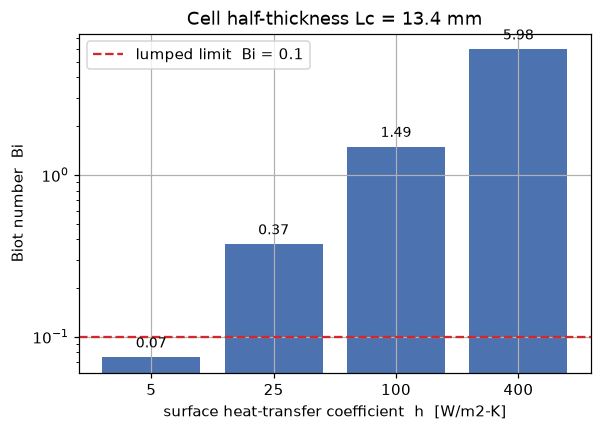

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([str(h) for h in h_list], Bi_list, color="#4C72B0")
ax.axhline(0.1, color="C3", ls="--", lw=1.5, label="lumped limit  Bi = 0.1")
ax.set_yscale("log")
ax.set_xlabel("surface heat-transfer coefficient  h  [W/m2-K]")
ax.set_ylabel("Biot number  Bi")
ax.set_title(f"Cell half-thickness Lc = {Lc*1e3:.1f} mm")
ax.legend()
for b, Bi in zip(bars, Bi_list):
    ax.text(b.get_x() + b.get_width() / 2, Bi * 1.15, f"{Bi:.2f}", ha="center", fontsize=9)
plt.show()

**What the plot shows**

* Under air cooling ($h = 5$) the cell sits just under $Bi = 0.1$ - one
  temperature is a fair description.
* Forced air and especially a liquid cold plate push $Bi$ well above the limit.
  A cold-plate-cooled cell has a real through-thickness gradient and cannot be
  treated as a single lump.
* This is why the cell model in my `BatteryTR` library splits the cell into a
  few through-plane nodes rather than one.

---
## Step 2 - Fourier number: how long does the transient last?

The **Fourier number** is dimensionless time for diffusion,

$$ Fo \;=\; \frac{\alpha\,t}{L_c^{\,2}}, \qquad \alpha \;=\; \frac{k}{\rho\,c_p} $$

where $\alpha$ is the thermal diffusivity. A diffusion transient is essentially
complete by $Fo \approx 1$, so $t \approx L_c^2/\alpha$ is the settling time.

### 2a. Parameters

In [5]:
rho_cell, cp_cell = 2400.0, 1000.0    # density [kg/m3], specific heat [J/kg-K]

### 2b. Compute diffusivity and settling time

In [6]:
alpha_cell = k_cell / (rho_cell * cp_cell)     # thermal diffusivity [m2/s]
t_settle = Lc**2 / alpha_cell                  # time to Fo ~ 1 [s]
print(f"alpha       = {alpha_cell:.2e} m2/s")
print(f"settling time (Fo = 1) = {t_settle:.0f} s  =  {t_settle/60:.1f} min")

alpha       = 3.75e-07 m2/s
settling time (Fo = 1) = 482 s  =  8.0 min


### 2c. Plot - the universal first-order approach, marked at Fo = 1

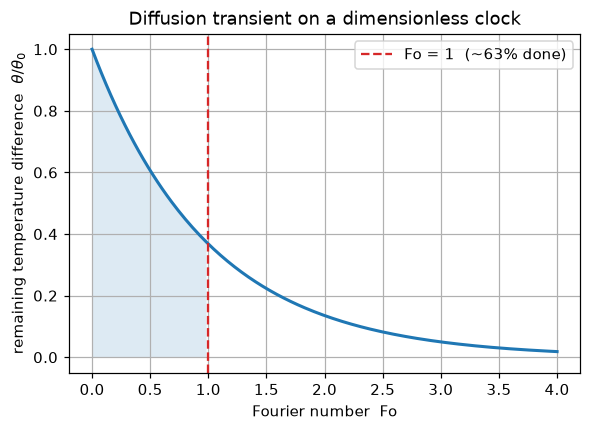

In [7]:
Fo = np.linspace(0, 4, 200)
theta = np.exp(-Fo)                    # normalised temperature difference (generic)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(Fo, theta, lw=2)
ax.axvline(1.0, color="C3", ls="--", label="Fo = 1  (~63% done)")
ax.fill_between(Fo, theta, where=(Fo <= 1), alpha=0.15)
ax.set_xlabel("Fourier number  Fo")
ax.set_ylabel(r"remaining temperature difference  $\theta/\theta_0$")
ax.set_title("Diffusion transient on a dimensionless clock")
ax.legend()
plt.show()

**What the plot shows**

* By $Fo = 1$ about 63% of the temperature change has happened; by $Fo = 3$ it
  is 95% complete.
* For this cell that maps to roughly 8 minutes - the timescale on which a
  thermal event or a step in cooling load plays out inside one cell.

---
## Step 3 - Lumped capacitance: the analytic transient

Take the body as one temperature $T(t)$. Energy balance with a constant internal
heat input $\dot Q$ and convective loss to ambient $T_\infty$:

$$ \rho V c_p \,\frac{dT}{dt} \;=\; \dot Q \;-\; h A_s \,\bigl(T - T_\infty\bigr) $$

This is linear and first order. Its exact solution is an exponential approach to
a steady value:

$$ T(t) \;=\; T_\infty + \frac{\dot Q}{h A_s}
   \;+\; \left(T_0 - T_\infty - \frac{\dot Q}{h A_s}\right) e^{-t/\tau},
   \qquad \tau \;=\; \frac{\rho V c_p}{h A_s} $$

$\tau$ is the time constant and $T_\infty + \dot Q/(hA_s)$ is the steady-state
temperature.

### 3a. Parameters

In [8]:
h_conv = 25.0                          # convection coefficient [W/m2-K]
Qgen = 15.0                            # steady internal heat [W]
T0 = 25.0                              # initial temperature [degC]
Tinf = 25.0                            # ambient temperature [degC]

### 3b. Compute the lumped constants and the analytic curve

In [9]:
C_th = rho_cell * cp_cell * V_cell     # heat capacity of the lump [J/K]
UA = h_conv * A_faces                  # overall conductance [W/K]
tau = C_th / UA                        # time constant [s]
T_ss = Tinf + Qgen / UA                # steady-state temperature [degC]
print(f"C_th = {C_th:.0f} J/K")
print(f"UA   = {UA:.2f} W/K")
print(f"tau  = {tau:.0f} s = {tau/60:.1f} min")
print(f"steady-state temperature = {T_ss:.2f} degC   (rise of {T_ss - Tinf:.2f} K)")

def T_analytic(t):
    return T_ss + (T0 - T_ss) * np.exp(-t / tau)

C_th = 869 J/K
UA   = 0.67 W/K
tau  = 1291 s = 21.5 min
steady-state temperature = 47.28 degC   (rise of 22.28 K)


### 3c. Plot

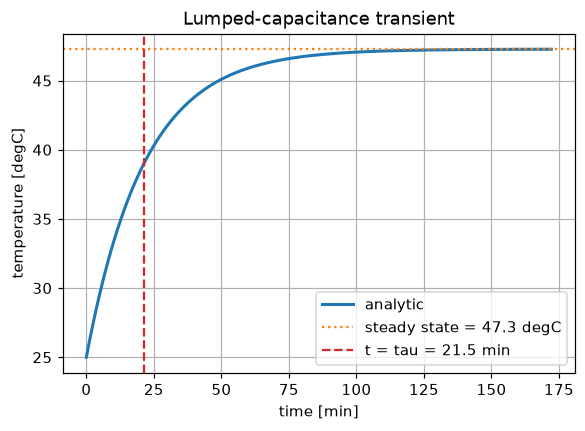

In [10]:
t = np.linspace(0, 8 * tau, 400)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t / 60, T_analytic(t), lw=2, label="analytic")
ax.axhline(T_ss, color="C1", ls=":", label=f"steady state = {T_ss:.1f} degC")
ax.axvline(tau / 60, color="C3", ls="--", label=f"t = tau = {tau/60:.1f} min")
ax.set_xlabel("time [min]")
ax.set_ylabel("temperature [degC]")
ax.set_title("Lumped-capacitance transient")
ax.legend()
plt.show()

**What the plot shows**

* The lump warms from 25 degC and levels off at 47.3 degC - the point where
  internal heat and convective loss balance.
* At $t = \tau$ it has covered 63% of that rise. This curve is the reference
  the numerical schemes below have to reproduce.

---
## Step 4 - Forward Euler: a first numerical solution

Most models cannot be solved on paper, so they are stepped forward in time.
The simplest scheme is **forward (explicit) Euler**: use the slope at the
current point to jump to the next one,

$$ T_{i+1} \;=\; T_i \;+\; \Delta t \; f(T_i),
   \qquad f(T) \;=\; \frac{\dot Q - U\!A\,(T - T_\infty)}{C_\text{th}} $$

### 4a. Define the right-hand side and the stepper

In [11]:
def rhs(T):
    return (Qgen - UA * (T - Tinf)) / C_th          # dT/dt  [K/s]

def forward_euler(dt, t_end):
    n = int(t_end / dt)
    T = np.empty(n + 1)
    T[0] = T0
    for i in range(n):
        T[i + 1] = T[i] + dt * rhs(T[i])
    return np.linspace(0, dt * n, n + 1), T

### 4b. Run at a small step ($\Delta t = 0.2\,\tau$)

In [12]:
dt_safe = 0.2 * tau
t_fe, T_fe = forward_euler(dt_safe, 8 * tau)
err_fe = np.max(np.abs(T_fe - T_analytic(t_fe)))
print(f"dt = {dt_safe:.0f} s = 0.2 tau")
print(f"max absolute error vs analytic = {err_fe:.3f} K")

dt = 258 s = 0.2 tau
max absolute error vs analytic = 0.895 K


### 4c. Plot

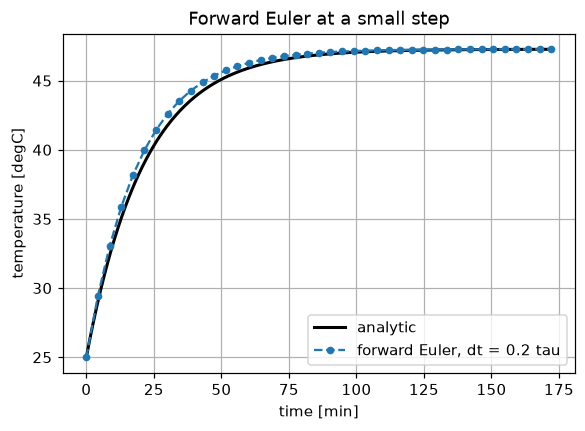

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t / 60, T_analytic(t), "k", lw=2, label="analytic")
ax.plot(t_fe / 60, T_fe, "o--", ms=4, color="C0", label="forward Euler, dt = 0.2 tau")
ax.set_xlabel("time [min]")
ax.set_ylabel("temperature [degC]")
ax.set_title("Forward Euler at a small step")
ax.legend()
plt.show()

**What the plot shows**

* With a small step the forward-Euler points sit right on the analytic curve;
  the largest gap is a fraction of a kelvin.
* The scheme works - as long as the step is small. Step 5 shows what "small"
  means.

---
## Step 5 - Forward Euler: the stability limit

For this linear problem forward Euler is only stable when

$$ \Delta t \;<\; 2\,\tau $$

Past that the numerical solution oscillates with a growing amplitude even though
the true solution is a smooth decay. Below I sweep the step size and watch it
happen.

### 5a. Run forward Euler at several step sizes

In [14]:
dt_factors = [0.5, 1.0, 1.8, 2.1]      # in units of tau
runs = {f: forward_euler(f * tau, 8 * tau) for f in dt_factors}

### 5b. Plot the solutions

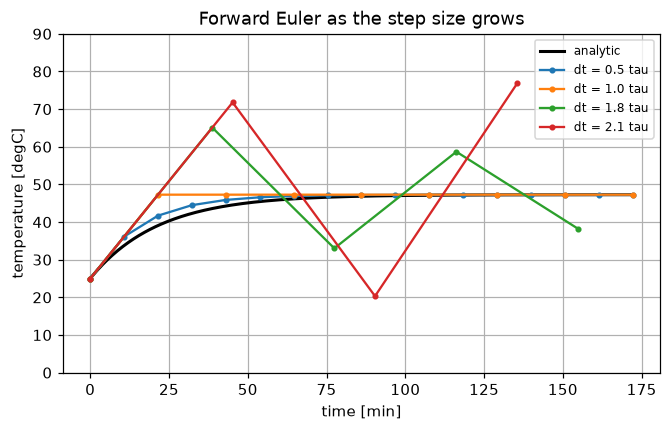

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t / 60, T_analytic(t), "k", lw=2, label="analytic")
for f, (tt, TT) in runs.items():
    ax.plot(tt / 60, TT, "o-", ms=3, label=f"dt = {f} tau")
ax.set_ylim(0, 90)
ax.set_xlabel("time [min]")
ax.set_ylabel("temperature [degC]")
ax.set_title("Forward Euler as the step size grows")
ax.legend(fontsize=8)
plt.show()

### 5c. Plot the error against the theoretical limit

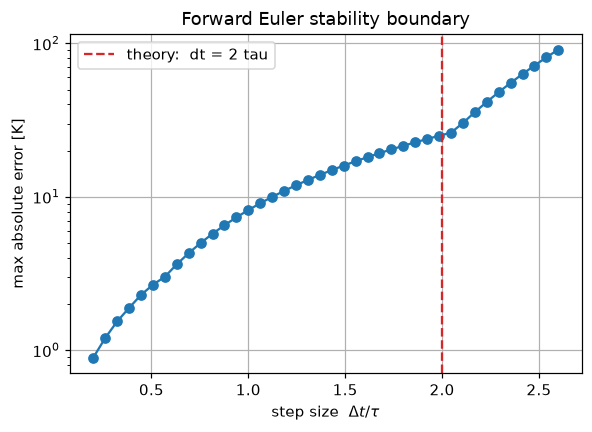

In [16]:
dts = np.linspace(0.2, 2.6, 40) * tau
max_err = []
for dt in dts:
    tt, TT = forward_euler(dt, 8 * tau)
    max_err.append(np.max(np.abs(TT - T_analytic(tt))))

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(dts / tau, max_err, "o-")
ax.axvline(2.0, color="C3", ls="--", label="theory:  dt = 2 tau")
ax.set_xlabel(r"step size  $\Delta t / \tau$")
ax.set_ylabel("max absolute error [K]")
ax.set_title("Forward Euler stability boundary")
ax.legend()
plt.show()

**What the plots show**

* At $\Delta t = 0.5\,\tau$ and $1.0\,\tau$ the scheme is accurate. At
  $1.8\,\tau$ it overshoots and rings. At $2.1\,\tau$ it diverges.
* The error curve turns almost vertically upward exactly at $\Delta t = 2\tau$,
  matching the theoretical limit.
* Practical lesson: an explicit scheme's step is capped by the *fastest* time
  constant in the model, even when you only care about the slow behaviour. That
  is the case for a battery pack (fast electrical, slow thermal) and the reason
  such models use implicit solvers.

---
## Step 6 - Backward Euler and RK4

Two ways to do better than forward Euler:

* **Backward (implicit) Euler** - use the slope at the *end* of the step,
  $\;T_{i+1} = T_i + \Delta t\, f(T_{i+1})$. For this linear problem it can be
  rearranged and solved directly. It is stable for any step size.
* **RK4** - four slope evaluations per step, combined so the error scales with
  $\Delta t^4$.

### 6a. Define both steppers

In [17]:
def backward_euler(dt, t_end):
    n = int(t_end / dt)
    T = np.empty(n + 1)
    T[0] = T0
    a = dt * UA / C_th
    for i in range(n):
        # T1 = T0 + dt*(Qgen - UA*(T1 - Tinf))/C_th   ->  solve for T1
        T[i + 1] = (T[i] + dt * (Qgen + UA * Tinf) / C_th) / (1 + a)
    return np.linspace(0, dt * n, n + 1), T

def rk4(dt, t_end):
    n = int(t_end / dt)
    T = np.empty(n + 1)
    T[0] = T0
    for i in range(n):
        k1 = rhs(T[i])
        k2 = rhs(T[i] + dt / 2 * k1)
        k3 = rhs(T[i] + dt / 2 * k2)
        k4 = rhs(T[i] + dt * k3)
        T[i + 1] = T[i] + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return np.linspace(0, dt * n, n + 1), T

### 6b. Run all three at a deliberately coarse step ($\Delta t = \tau$)

In [18]:
dt_coarse = 1.0 * tau
t_fe2, T_fe2 = forward_euler(dt_coarse, 8 * tau)
t_be2, T_be2 = backward_euler(dt_coarse, 8 * tau)
t_rk2, T_rk2 = rk4(dt_coarse, 8 * tau)
for name, tt, TT in [("forward Euler", t_fe2, T_fe2),
                     ("backward Euler", t_be2, T_be2),
                     ("RK4", t_rk2, T_rk2)]:
    print(f"{name:15s} max error = {np.max(np.abs(TT - T_analytic(tt))):.3f} K")

forward Euler   max error = 8.195 K
backward Euler  max error = 2.943 K
RK4             max error = 0.159 K


### 6c. Plot

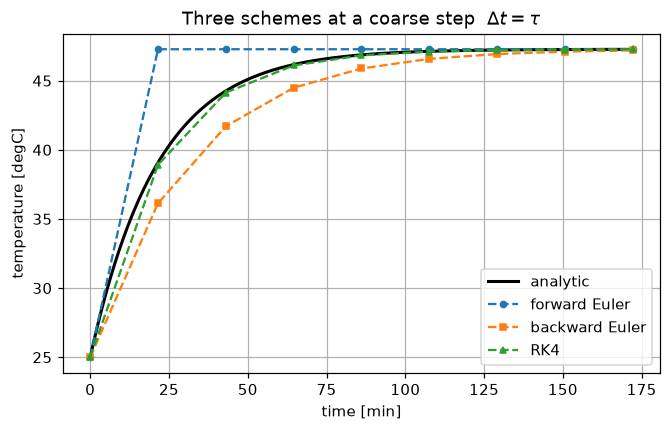

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t / 60, T_analytic(t), "k", lw=2, label="analytic")
ax.plot(t_fe2 / 60, T_fe2, "o--", ms=4, label="forward Euler")
ax.plot(t_be2 / 60, T_be2, "s--", ms=4, label="backward Euler")
ax.plot(t_rk2 / 60, T_rk2, "^--", ms=4, label="RK4")
ax.set_xlabel("time [min]")
ax.set_ylabel("temperature [degC]")
ax.set_title(r"Three schemes at a coarse step  $\Delta t = \tau$")
ax.legend()
plt.show()

**What the plot shows**

* At $\Delta t = \tau$ forward Euler overshoots badly.
* Backward Euler stays stable and monotonic but lags the true curve - stable is
  not the same as accurate.
* RK4 is visually on top of the analytic solution even at this coarse step.

---
## Step 7 - Order of accuracy

The global error of a scheme scales as $\Delta t^{\,p}$. Halving the step should
divide the error by $2^p$. Expected: $p = 1$ for both Euler schemes, $p = 4$ for
RK4. Below, the slope on a log-log plot *is* $p$.

### 7a. Sweep the step size for each scheme

In [20]:
steps = np.array([tau / 2, tau / 4, tau / 8, tau / 16, tau / 32])
errors = {"forward Euler": [], "backward Euler": [], "RK4": []}
for dt in steps:
    for name, fn in [("forward Euler", forward_euler),
                     ("backward Euler", backward_euler),
                     ("RK4", rk4)]:
        tt, TT = fn(dt, 8 * tau)
        errors[name].append(np.max(np.abs(TT - T_analytic(tt))))

### 7b. Plot error vs step size (log-log), with reference slopes

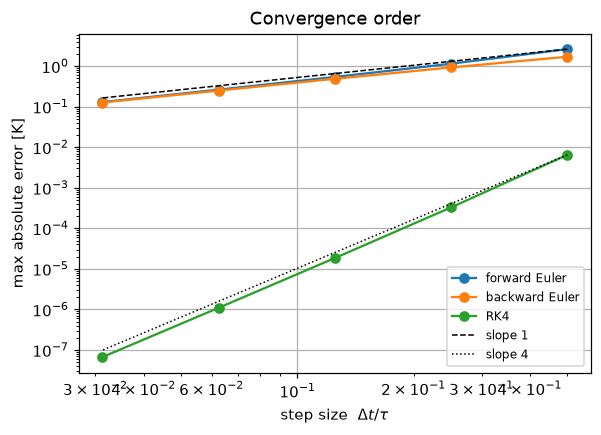

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, e in errors.items():
    ax.loglog(steps / tau, e, "o-", label=name)
ref = steps / tau
fe0, rk0 = errors["forward Euler"][0], errors["RK4"][0]
ax.loglog(ref, fe0 * (ref / ref[0])**1, "k--", lw=1, label="slope 1")
ax.loglog(ref, rk0 * (ref / ref[0])**4, "k:", lw=1, label="slope 4")
ax.set_xlabel(r"step size  $\Delta t / \tau$")
ax.set_ylabel("max absolute error [K]")
ax.set_title("Convergence order")
ax.legend(fontsize=8)
plt.show()

**What the plot shows**

* Both Euler curves run parallel to the slope-1 reference: first order.
* RK4 runs parallel to the slope-4 reference and is already at round-off by the
  smaller steps.
* Choosing a scheme is a trade: RK4 buys accuracy per step, implicit schemes buy
  stability for stiff problems.

---
## Step 8 - 1-D steady conduction with heat generation (analytic)

Now a space problem instead of a time problem. A plane wall of thickness $L$
with uniform volumetric heat generation $\dot q$, both faces held at $T_s$:

$$ k\,\frac{d^2 T}{dx^2} \;+\; \dot q \;=\; 0 $$

Integrating twice with $T(\pm L/2) = T_s$ gives a parabola:

$$ T(x) \;=\; T_s \;+\; \frac{\dot q}{2k}\left(\frac{L^2}{4} - x^2\right) $$

The peak is at the centre.

### 8a. Parameters

In [22]:
L = 0.02                               # wall thickness [m]
q_vol = 4.0e4                          # volumetric heat generation [W/m3]
k_w = 1.5                              # wall conductivity [W/m-K]
Ts = 40.0                              # face temperature [degC]

### 8b. Evaluate the analytic profile

In [23]:
def T_wall(x):
    return Ts + q_vol / (2 * k_w) * (L**2 / 4 - x**2)

x_fine = np.linspace(-L / 2, L / 2, 200)
T_peak = T_wall(0.0)
print(f"centre-line peak temperature = {T_peak:.3f} degC  (rise of {T_peak - Ts:.3f} K)")

centre-line peak temperature = 41.333 degC  (rise of 1.333 K)


### 8c. Plot

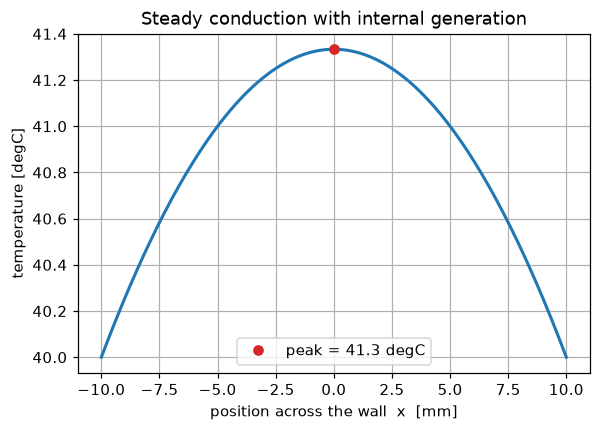

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_fine * 1e3, T_wall(x_fine), lw=2)
ax.plot(0, T_peak, "o", color="C3", label=f"peak = {T_peak:.1f} degC")
ax.set_xlabel("position across the wall  x  [mm]")
ax.set_ylabel("temperature [degC]")
ax.set_title("Steady conduction with internal generation")
ax.legend()
plt.show()

**What the plot shows**

* The profile is a symmetric parabola with the hottest point at the centre,
  where heat has the furthest to travel to reach a cooled face.
* This closed form is the target for the finite-difference solver in Step 9.

---
## Step 9 - Finite differences and grid convergence

Replace the second derivative with a central difference on a grid of $N$ points,

$$ \frac{T_{i-1} - 2 T_i + T_{i+1}}{\Delta x^2} \;=\; -\,\frac{\dot q}{k} $$

which, with the two fixed-temperature end points, is a linear system solved in
one shot. Then refine the grid and check that the error falls at second order.

### 9a. The solver

In [25]:
def fd_solve(N):
    x = np.linspace(-L / 2, L / 2, N)
    dx = x[1] - x[0]
    A = np.zeros((N, N))
    b = np.zeros(N)
    A[0, 0] = A[-1, -1] = 1.0                 # Dirichlet end points
    b[0] = b[-1] = Ts
    for i in range(1, N - 1):
        A[i, i - 1], A[i, i], A[i, i + 1] = 1.0, -2.0, 1.0
        b[i] = -q_vol * dx**2 / k_w
    return x, np.linalg.solve(A, b)

### 9b. Solve on three grids and compare to the analytic profile

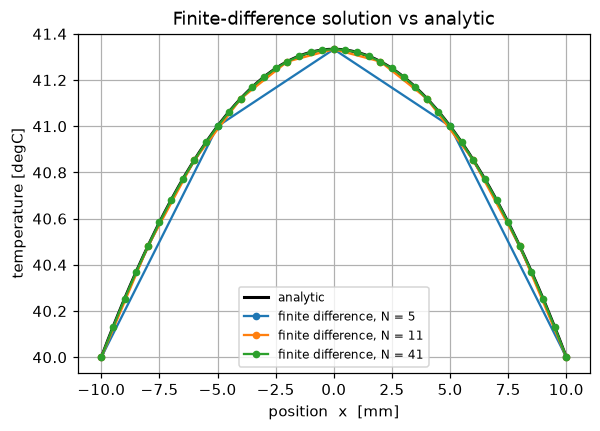

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_fine * 1e3, T_wall(x_fine), "k", lw=2, label="analytic")
for N in [5, 11, 41]:
    xg, Tg = fd_solve(N)
    ax.plot(xg * 1e3, Tg, "o-", ms=4, label=f"finite difference, N = {N}")
ax.set_xlabel("position  x  [mm]")
ax.set_ylabel("temperature [degC]")
ax.set_title("Finite-difference solution vs analytic")
ax.legend(fontsize=8)
plt.show()

### 9c. Grid-convergence check

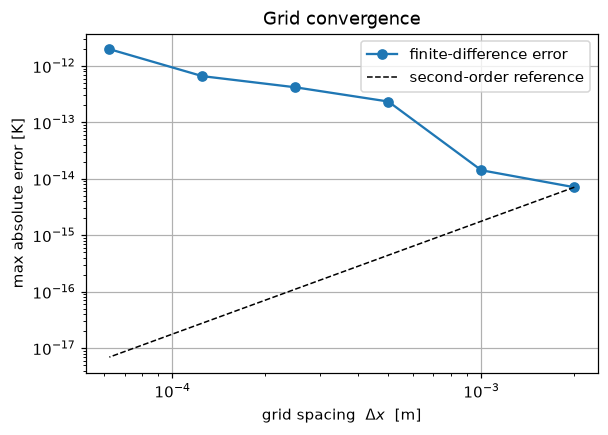

finest grid (N = 321): peak error = 1.99e-12 K


In [27]:
Ns = [11, 21, 41, 81, 161, 321]
dx_list, err_list = [], []
for N in Ns:
    xg, Tg = fd_solve(N)
    dx_list.append(L / (N - 1))
    err_list.append(np.max(np.abs(Tg - T_wall(xg))))

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(dx_list, err_list, "o-", label="finite-difference error")
ax.loglog(dx_list, np.array(dx_list)**2 * err_list[0] / dx_list[0]**2,
          "k--", lw=1, label="second-order reference")
ax.set_xlabel(r"grid spacing  $\Delta x$  [m]")
ax.set_ylabel("max absolute error [K]")
ax.set_title("Grid convergence")
ax.legend()
plt.show()

print(f"finest grid (N = {Ns[-1]}): peak error = {err_list[-1]:.2e} K")

**What the plots show**

* Even $N = 5$ catches the shape; by $N = 41$ the finite-difference points sit
  on the analytic curve.
* The error runs parallel to the second-order reference line - halving the
  spacing quarters the error - and reaches round-off on the finest grid.
* That is the "validate before you use it" step: the discretisation is trusted
  because it reproduces a case with a known answer.

---
## Running log

| date | change |
|---|---|
| 2026-09-03 | Created (split out of the old combined notebook). |
| 2026-09-03 | Rebuilt in small steps: each step is parameters -> one calculation -> one plot -> a note on the plot. Equations moved to display form. |